# Notebook 1: EDA and Dataset Analysis
**MarathiMWP Thesis — Chapter 3: Dataset Creation**

This notebook generates all dataset statistics and visualizations needed for Chapter 3.

**Outputs:**
- Dataset statistics table (Table 3.1)
- Operator distribution chart (Figure 3.1)
- Problem length distribution (Figure 3.2)
- Comparison with HAWP (Table 3.2)
- Train/Val/Test splits saved to `splits/`

In [ ]:
# Install dependencies (run once)
# pip install matplotlib seaborn pandas numpy sympy sacrebleu

SyntaxError: invalid syntax (265002559.py, line 2)

In [2]:
import sys
import json
import re
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from pathlib import Path
from collections import Counter

# Add utils to path
sys.path.insert(0, str(Path('.').resolve()))
from utils.data_utils import (
    load_marathi, load_hawp, extract_numbers, extract_equation_answer,
    stratified_split, save_splits, classify_operation, get_operators_in_equation
)

# Use a font that supports Devanagari — fallback to default if unavailable
try:
    matplotlib.rcParams['font.family'] = ['Noto Sans Devanagari', 'DejaVu Sans']
except Exception:
    pass

plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')
print('Setup complete')

Setup complete


## 1. Load Data

In [3]:
marathi_data = load_marathi()
hawp_data    = load_hawp()

print(f'MarathiMWP  : {len(marathi_data):,} problems')
print(f'HAWP (Hindi): {len(hawp_data):,} problems')
print()
print('Sample Marathi problem:')
print(json.dumps(marathi_data[0], ensure_ascii=False, indent=2))

MarathiMWP  : 2,336 problems
HAWP (Hindi): 2,336 problems

Sample Marathi problem:
{
  "pIndex": 0,
  "Problem": "सोहनने 7.423 किलो तांदूळ आणि 6.129 किलो डाळ खरेदी केली. सोहनने एकूण किती खरेदी केली?",
  "Equation": "X = ( 7.423 + 6.129 )",
  "Relevant Indices": [
    0,
    1
  ],
  "Number of Operators": 1
}


In [4]:
# Convert to DataFrames for easy analysis
df_m = pd.DataFrame(marathi_data)
df_h = pd.DataFrame(hawp_data)

# Add derived columns
df_m['word_count']   = df_m['Problem'].apply(lambda x: len(x.split()))
df_m['char_count']   = df_m['Problem'].apply(len)
df_m['operation']    = df_m['Equation'].apply(classify_operation)
df_m['answer']       = df_m['Equation'].apply(extract_equation_answer)
df_m['has_implicit'] = df_m['Relevant Indices'].apply(
    lambda x: 'implicit' in [str(i) for i in x])
df_m['has_decimal']  = df_m['Problem'].apply(
    lambda x: bool(re.search(r'\d+\.\d+', x)))

df_h['word_count']   = df_h['Problem'].apply(lambda x: len(x.split()))

print(df_m[['word_count', 'Number of Operators', 'operation']].describe().round(2))

       word_count  Number of Operators
count     2336.00              2336.00
mean        20.31                 1.23
std          6.90                 0.43
min          6.00                 0.00
25%         15.00                 1.00
50%         19.00                 1.00
75%         24.00                 1.00
max         61.00                 2.00


## 2. Dataset Statistics (Table 3.1)

In [5]:
stats = {
    'Total Problems'          : len(df_m),
    'Avg Words per Problem'   : f"{df_m['word_count'].mean():.1f}",
    'Min / Max Words'         : f"{df_m['word_count'].min()} / {df_m['word_count'].max()}",
    'Avg Operators'           : f"{df_m['Number of Operators'].mean():.2f}",
    'Single-op Problems'      : (df_m['Number of Operators'] == 1).sum(),
    'Multi-op Problems'       : (df_m['Number of Operators'] >= 2).sum(),
    'Implicit Number Problems': df_m['has_implicit'].sum(),
    'Decimal Problems'        : df_m['has_decimal'].sum(),
    'Unique Operations'       : df_m['operation'].nunique(),
}

print('\nMarathiMWP Dataset Statistics')
print('=' * 42)
for k, v in stats.items():
    print(f"  {k:<30} : {v}")


MarathiMWP Dataset Statistics
  Total Problems                 : 2336
  Avg Words per Problem          : 20.3
  Min / Max Words                : 6 / 61
  Avg Operators                  : 1.23
  Single-op Problems             : 1786
  Multi-op Problems              : 547
  Implicit Number Problems       : 90
  Decimal Problems               : 278
  Unique Operations              : 5


## 3. Operator Distribution (Figure 3.1)

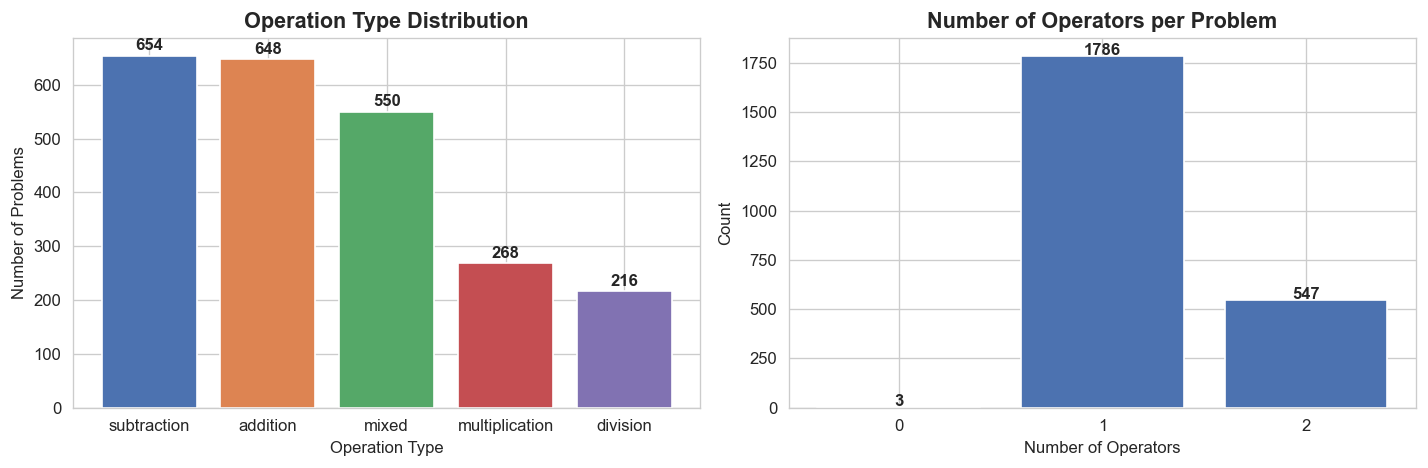

Saved: figures/fig_3_1_operator_distribution.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: Operation type distribution
op_counts = df_m['operation'].value_counts()
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']
axes[0].bar(op_counts.index, op_counts.values, color=colors[:len(op_counts)])
axes[0].set_title('Operation Type Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Operation Type')
axes[0].set_ylabel('Number of Problems')
for i, (idx, val) in enumerate(op_counts.items()):
    axes[0].text(i, val + 10, str(val), ha='center', fontweight='bold')

# Right: Number of operators
nop_counts = df_m['Number of Operators'].value_counts().sort_index()
axes[1].bar(nop_counts.index.astype(str), nop_counts.values, color='#4C72B0')
axes[1].set_title('Number of Operators per Problem', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Operators')
axes[1].set_ylabel('Count')
for i, (idx, val) in enumerate(nop_counts.items()):
    axes[1].text(i, val + 5, str(val), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('figures/fig_3_1_operator_distribution.png', bbox_inches='tight')
plt.show()
print('Saved: figures/fig_3_1_operator_distribution.png')

## 4. Problem Length Distribution (Figure 3.2)

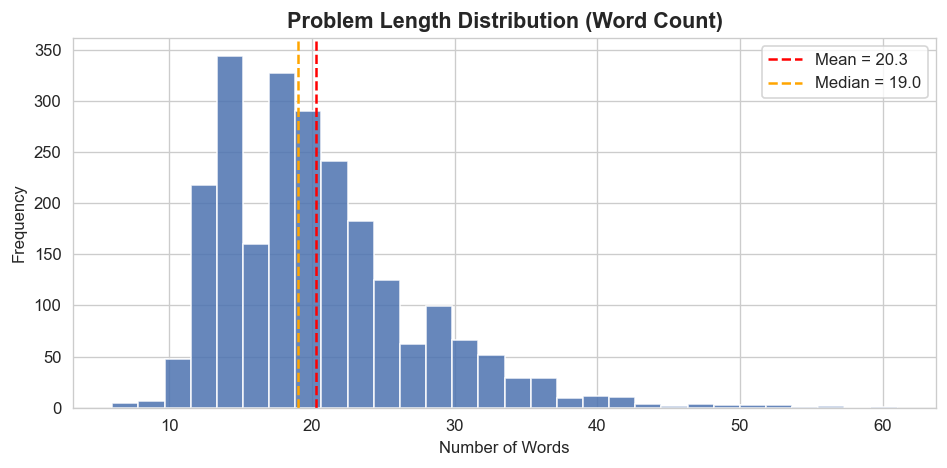

Saved: figures/fig_3_2_length_distribution.png


In [8]:
Path('figures').mkdir(exist_ok=True)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df_m['word_count'], bins=30, edgecolor='white', color='#4C72B0', alpha=0.85)
ax.axvline(df_m['word_count'].mean(), color='red', linestyle='--',
           label=f"Mean = {df_m['word_count'].mean():.1f}")
ax.axvline(df_m['word_count'].median(), color='orange', linestyle='--',
           label=f"Median = {df_m['word_count'].median():.1f}")
ax.set_title('Problem Length Distribution (Word Count)', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Words')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.savefig('figures/fig_3_2_length_distribution.png', bbox_inches='tight')
plt.show()
print('Saved: figures/fig_3_2_length_distribution.png')

## 5. Equation Complexity Analysis

Operator Frequency in Equations:
-----------------------------------
  Addition        : 1259  (43.7%)
  Subtraction     :  965  (33.5%)
  Multiplication  :  371  (12.9%)
  Division        :  285  (9.9%)


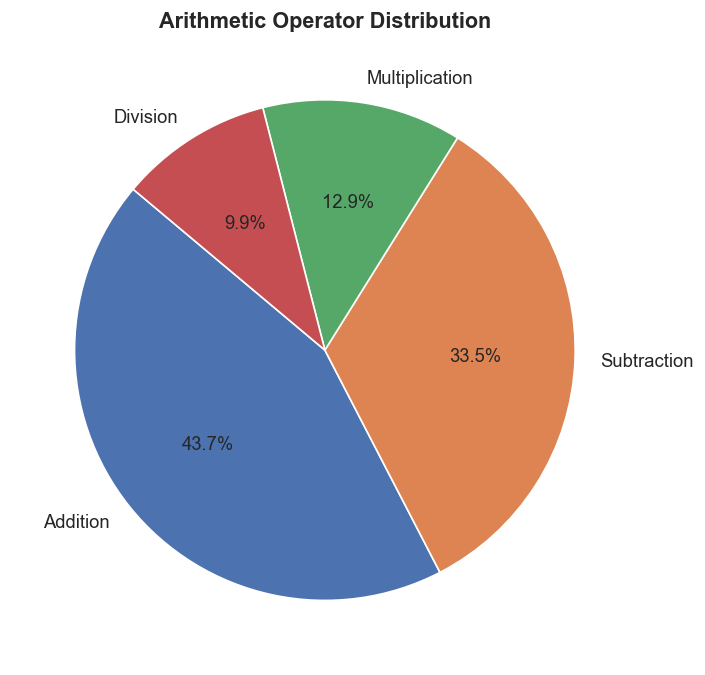

In [9]:
# Operator frequency breakdown
all_ops = []
for eq in df_m['Equation']:
    all_ops.extend(get_operators_in_equation(eq))

op_freq = Counter(all_ops)
op_labels = {'+': 'Addition', '-': 'Subtraction', '*': 'Multiplication', '/': 'Division'}

print('Operator Frequency in Equations:')
print('-' * 35)
total_ops = sum(op_freq.values())
for op in ['+', '-', '*', '/']:
    cnt = op_freq.get(op, 0)
    print(f"  {op_labels[op]:<15} : {cnt:4d}  ({cnt/total_ops*100:.1f}%)")

# Pie chart
fig, ax = plt.subplots(figsize=(6, 6))
labels = [op_labels[o] for o in ['+', '-', '*', '/'] if op_freq.get(o, 0) > 0]
sizes  = [op_freq[o] for o in ['+', '-', '*', '/'] if op_freq.get(o, 0) > 0]
ax.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors[:len(labels)],
       startangle=140, textprops={'fontsize': 11})
ax.set_title('Arithmetic Operator Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fig_3_3_operator_pie.png', bbox_inches='tight')
plt.show()

## 6. Comparison with HAWP (Table 3.2)

In [10]:
df_h['operation'] = df_h['Equation'].apply(classify_operation)

comparison = pd.DataFrame({
    'Metric': [
        'Total Problems', 'Avg Word Count', 'Std Word Count',
        'Single-op (%)', 'Multi-op (%)',
        'Addition (%)', 'Subtraction (%)', 'Multiplication (%)', 'Division (%)', 'Mixed (%)',
    ],
    'MarathiMWP': [
        len(df_m),
        f"{df_m['word_count'].mean():.1f}",
        f"{df_m['word_count'].std():.1f}",
        f"{(df_m['Number of Operators']==1).mean()*100:.1f}%",
        f"{(df_m['Number of Operators']>=2).mean()*100:.1f}%",
    ] + [
        f"{(df_m['operation']==op).mean()*100:.1f}%"
        for op in ['addition','subtraction','multiplication','division','mixed']
    ],
    'HAWP (Hindi)': [
        len(df_h),
        f"{df_h['word_count'].mean():.1f}",
        f"{df_h['word_count'].std():.1f}",
        f"{(df_h['Number of Operators']==1).mean()*100:.1f}%",
        f"{(df_h['Number of Operators']>=2).mean()*100:.1f}%",
    ] + [
        f"{(df_h['operation']==op).mean()*100:.1f}%"
        for op in ['addition','subtraction','multiplication','division','mixed']
    ],
})

print('\nDataset Comparison: MarathiMWP vs HAWP')
print(comparison.to_string(index=False))

# Save for thesis
comparison.to_csv('figures/table_3_2_dataset_comparison.csv', index=False)
print('\nSaved: figures/table_3_2_dataset_comparison.csv')


Dataset Comparison: MarathiMWP vs HAWP
            Metric MarathiMWP HAWP (Hindi)
    Total Problems       2336         2336
    Avg Word Count       20.3         26.6
    Std Word Count        6.9          8.9
     Single-op (%)      76.5%        76.5%
      Multi-op (%)      23.4%        23.4%
      Addition (%)      27.7%        27.7%
   Subtraction (%)      28.0%        28.0%
Multiplication (%)      11.5%        11.5%
      Division (%)       9.2%         9.2%
         Mixed (%)      23.5%        23.5%

Saved: figures/table_3_2_dataset_comparison.csv


## 7. Vocabulary Analysis

In [11]:
all_words = []
for problem in df_m['Problem']:
    all_words.extend(problem.split())

vocab = Counter(all_words)
print(f'Total tokens      : {len(all_words):,}')
print(f'Vocabulary size   : {len(vocab):,}')
print(f'Avg word length   : {np.mean([len(w) for w in all_words]):.1f} chars')
print(f'\nTop 20 most common words:')
for word, count in vocab.most_common(20):
    print(f'  {word:<20} : {count}')

Total tokens      : 47,451
Vocabulary size   : 8,130
Avg word length   : 5.2 chars

Top 20 most common words:
  किती                 : 2247
  आणि                  : 1102
  1                    : 702
  आहेत.                : 698
  आहेत?                : 694
  एकूण                 : 603
  तर                   : 515
  जर                   : 420
  रुपये                : 407
  तिने                 : 381
  आता                  : 372
  त्याने               : 370
  होते.                : 329
  आहे.                 : 306
  आणखी                 : 266
  एका                  : 260
  प्रत्येक             : 249
  विकत                 : 238
  3                    : 223
  होती.                : 215


In [12]:
# Marathi mathematical keywords found in dataset
math_keywords = {
    'एकूण': 'total/sum',
    'किती': 'how many/much',
    'वजा': 'subtract',
    'बेरीज': 'addition/sum',
    'गुणा': 'multiply',
    'भागा': 'divide',
    'शिल्लक': 'remaining',
    'जास्त': 'more',
    'कमी': 'less',
    'प्रत्येक': 'each',
    'फरक': 'difference',
    'मिळून': 'together',
}

print('Marathi Math Keywords in Dataset:')
print('-' * 45)
for kw, meaning in sorted(math_keywords.items(), key=lambda x: vocab.get(x[0], 0), reverse=True):
    count = vocab.get(kw, 0)
    print(f"  {kw:<12} ({meaning:<20}): {count:4d} occurrences")

Marathi Math Keywords in Dataset:
---------------------------------------------
  किती         (how many/much       ): 2247 occurrences
  एकूण         (total/sum           ):  603 occurrences
  प्रत्येक     (each                ):  249 occurrences
  शिल्लक       (remaining           ):  200 occurrences
  जास्त        (more                ):   42 occurrences
  कमी          (less                ):   32 occurrences
  मिळून        (together            ):   23 occurrences
  फरक          (difference          ):    9 occurrences
  बेरीज        (addition/sum        ):    4 occurrences
  वजा          (subtract            ):    0 occurrences
  गुणा         (multiply            ):    0 occurrences
  भागा         (divide              ):    0 occurrences


## 8. Number Analysis

In [13]:
answers = df_m['answer'].dropna()

print('Answer Distribution:')
print(f'  Min answer    : {answers.min()}')
print(f'  Max answer    : {answers.max()}')
print(f'  Mean answer   : {answers.mean():.2f}')
print(f'  Median answer : {answers.median():.2f}')
print(f'  Decimal answers: {(answers % 1 != 0).sum()} ({(answers % 1 != 0).mean()*100:.1f}%)')
print(f'  Integer answers: {(answers % 1 == 0).sum()} ({(answers % 1 == 0).mean()*100:.1f}%)')

# Answer range buckets
buckets = pd.cut(answers.clip(upper=10000), bins=[0,10,100,1000,10000],
                 labels=['0-10','10-100','100-1000','1000+'])
print('\nAnswer Range Distribution:')
print(buckets.value_counts().sort_index().to_string())

Answer Distribution:
  Min answer    : 0.08
  Max answer    : 18070416.0
  Mean answer   : 12770.97
  Median answer : 36.00
  Decimal answers: 294 (12.7%)
  Integer answers: 2029 (87.3%)

Answer Range Distribution:
answer
0-10         596
10-100      1090
100-1000     366
1000+        271


## 9. Train / Val / Test Splits

In [14]:
train, val, test = stratified_split(marathi_data, train_ratio=0.70, val_ratio=0.15, seed=42)

print('Split Summary (stratified by Number of Operators):')
print(f'  Train : {len(train):4d} ({len(train)/len(marathi_data)*100:.1f}%)')
print(f'  Val   : {len(val):4d} ({len(val)/len(marathi_data)*100:.1f}%)')
print(f'  Test  : {len(test):4d} ({len(test)/len(marathi_data)*100:.1f}%)')

# Verify distribution is preserved
for split_name, split in [('Train', train), ('Val', val), ('Test', test)]:
    ops = Counter(x['Number of Operators'] for x in split)
    print(f"  {split_name} op distribution: {dict(sorted(ops.items()))}")

Split Summary (stratified by Number of Operators):
  Train : 1634 (69.9%)
  Val   :  349 (14.9%)
  Test  :  353 (15.1%)
  Train op distribution: {0: 2, 1: 1250, 2: 382}
  Val op distribution: {1: 267, 2: 82}
  Test op distribution: {0: 1, 1: 269, 2: 83}


In [15]:
save_splits(train, val, test, lang='marathi')

# Also save HAWP splits for cross-lingual experiments
hawp_train, hawp_val, hawp_test = stratified_split(hawp_data, train_ratio=0.70, val_ratio=0.15, seed=42)
save_splits(hawp_train, hawp_val, hawp_test, lang='hawp')
print('All splits saved.')

Saved marathi_train.json: 1634 problems
Saved marathi_val.json: 349 problems
Saved marathi_test.json: 353 problems
Saved hawp_train.json: 1634 problems
Saved hawp_val.json: 349 problems
Saved hawp_test.json: 353 problems
All splits saved.


## 10. Split Distribution Visualization (Figure 3.4)

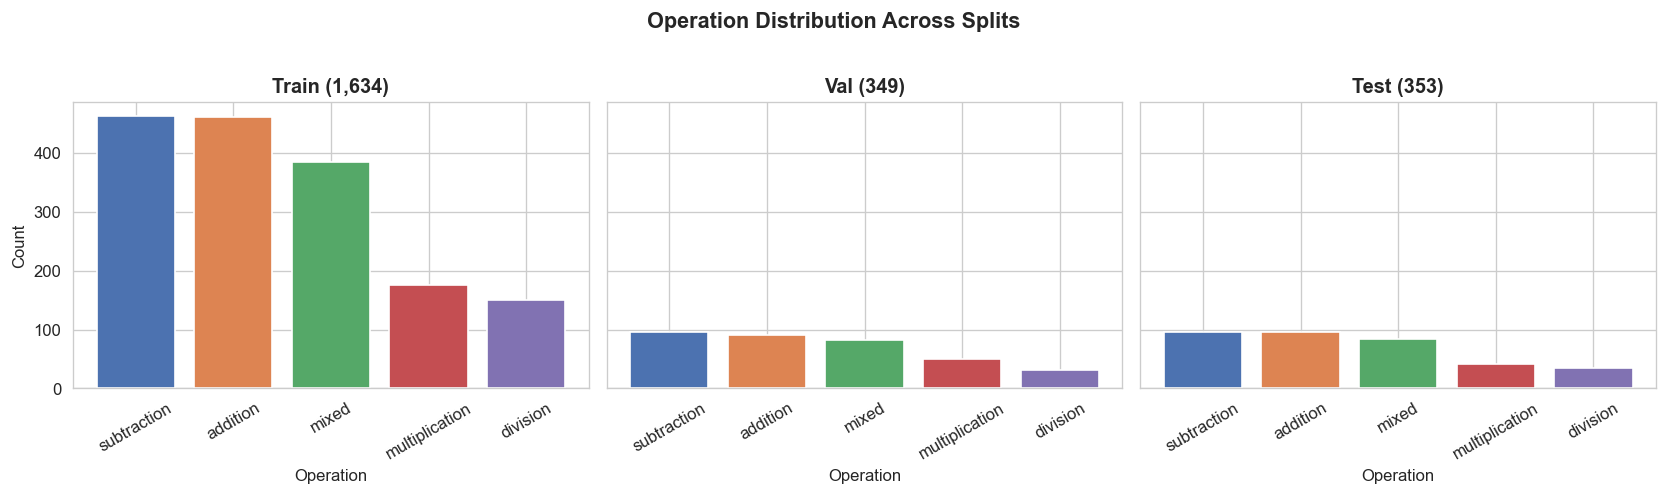

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, (split_name, split) in zip(axes, [('Train', train), ('Val', val), ('Test', test)]):
    df_split = pd.DataFrame(split)
    df_split['operation'] = df_split['Equation'].apply(classify_operation)
    op_cnt = df_split['operation'].value_counts()
    ax.bar(op_cnt.index, op_cnt.values, color=colors[:len(op_cnt)])
    ax.set_title(f'{split_name} ({len(split):,})', fontsize=12, fontweight='bold')
    ax.set_xlabel('Operation')
    if ax == axes[0]:
        ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Operation Distribution Across Splits', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/fig_3_4_split_distribution.png', bbox_inches='tight')
plt.show()

## 11. Summary Table for Thesis

In [17]:
print('\n' + '='*60)
print('  DATASET SUMMARY — For Chapter 3 of Thesis')
print('='*60)
print(f'  Total problems       : {len(marathi_data)}')
print(f'  Training set         : {len(train)} (70%)')
print(f'  Validation set       : {len(val)} (15%)')
print(f'  Test set             : {len(test)} (15%)')
print(f'  Avg words/problem    : {df_m["word_count"].mean():.1f}')
print(f'  Vocabulary size      : {len(vocab):,}')
print(f'  Single-step problems : {(df_m["Number of Operators"]==1).sum()}')
print(f'  Multi-step problems  : {(df_m["Number of Operators"]>=2).sum()}')
print(f'  Implicit numbers     : {df_m["has_implicit"].sum()}')
print(f'  Decimal problems     : {df_m["has_decimal"].sum()}')
print()
print('  Operation Breakdown:')
for op in ['addition','subtraction','multiplication','division','mixed']:
    cnt = (df_m['operation'] == op).sum()
    print(f'    {op:<15} : {cnt:4d} ({cnt/len(df_m)*100:.1f}%)')
print('='*60)


  DATASET SUMMARY — For Chapter 3 of Thesis
  Total problems       : 2336
  Training set         : 1634 (70%)
  Validation set       : 349 (15%)
  Test set             : 353 (15%)
  Avg words/problem    : 20.3
  Vocabulary size      : 8,130
  Single-step problems : 1786
  Multi-step problems  : 547
  Implicit numbers     : 90
  Decimal problems     : 278

  Operation Breakdown:
    addition        :  648 (27.7%)
    subtraction     :  654 (28.0%)
    multiplication  :  268 (11.5%)
    division        :  216 (9.2%)
    mixed           :  550 (23.5%)
